In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

import processing as proc
import metricas
import dataset

In [ ]:
## Funcoes Aux




(<PIL.Image.Image image mode=RGB size=64x64 at 0x7FC301388170>, array([3]))
No module named 'pyopencl'


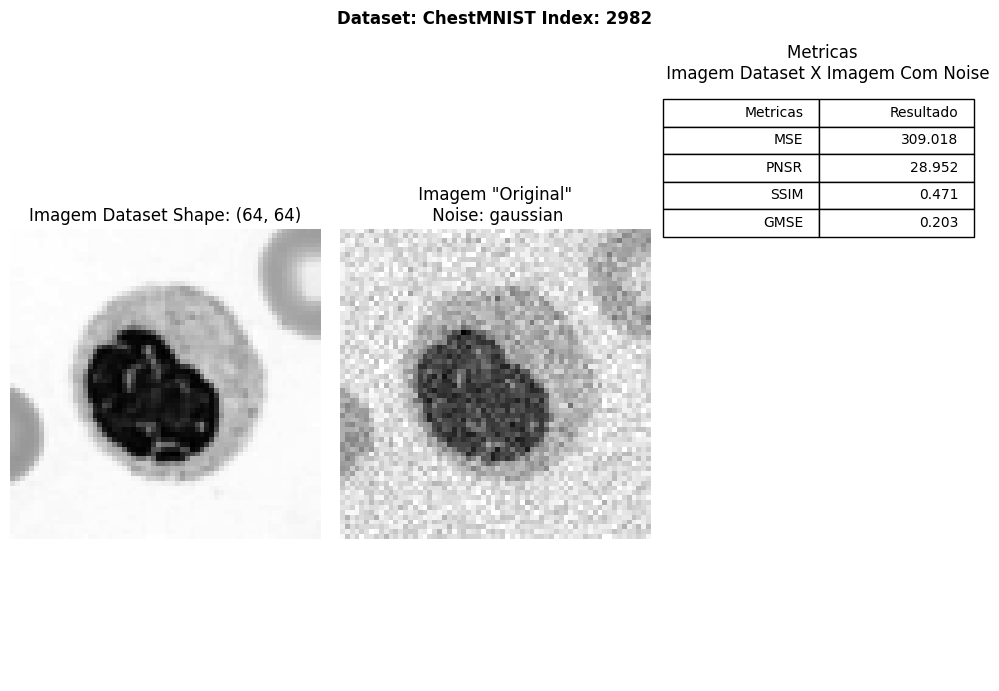

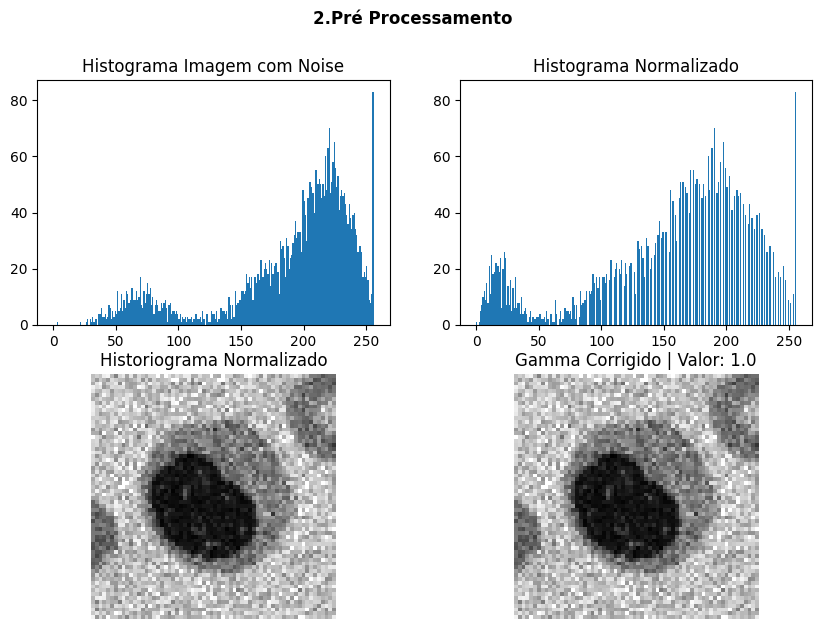

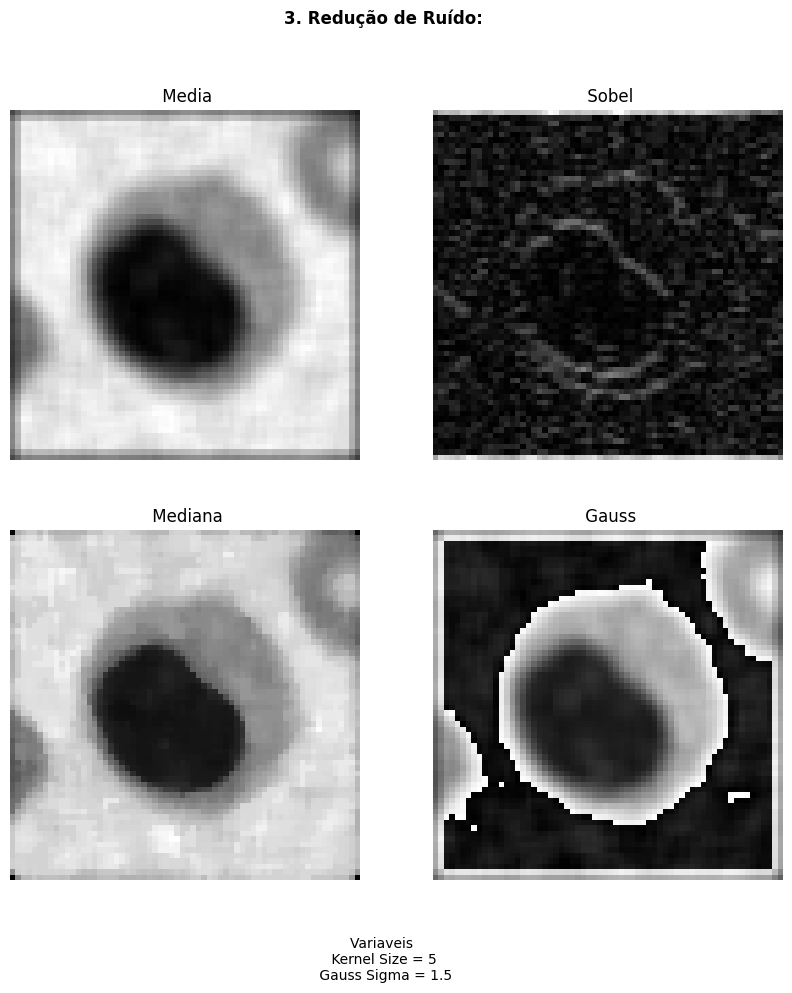

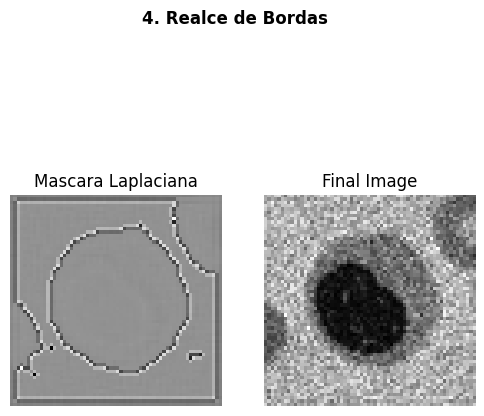

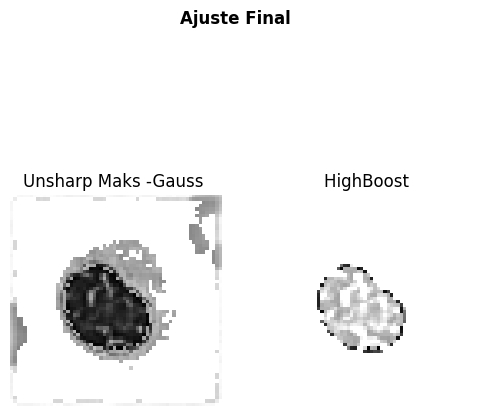

No module named 'pyopencl'


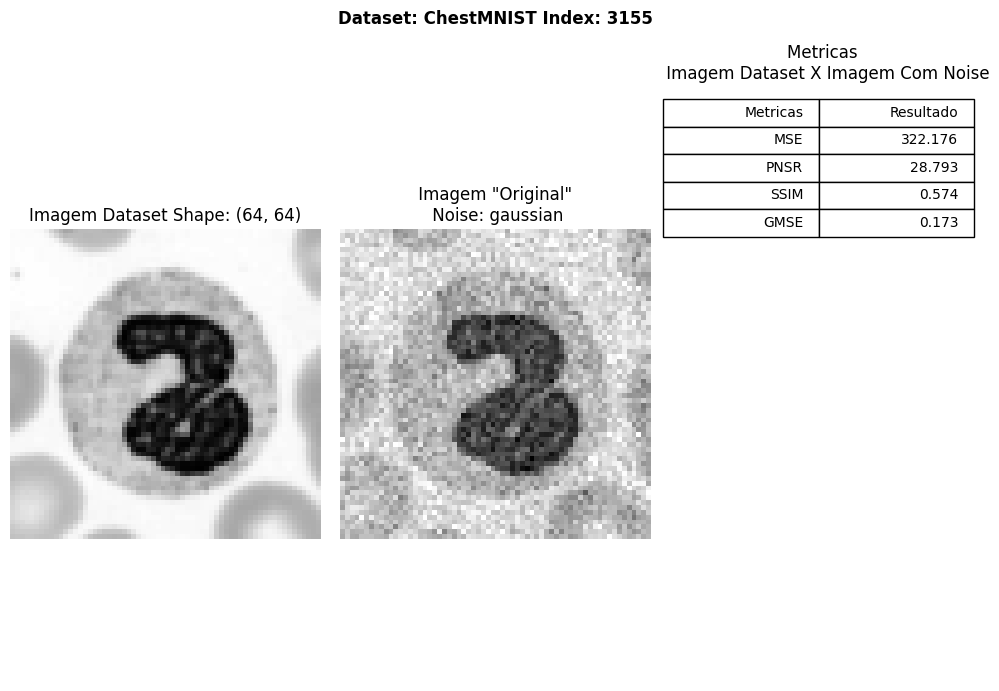

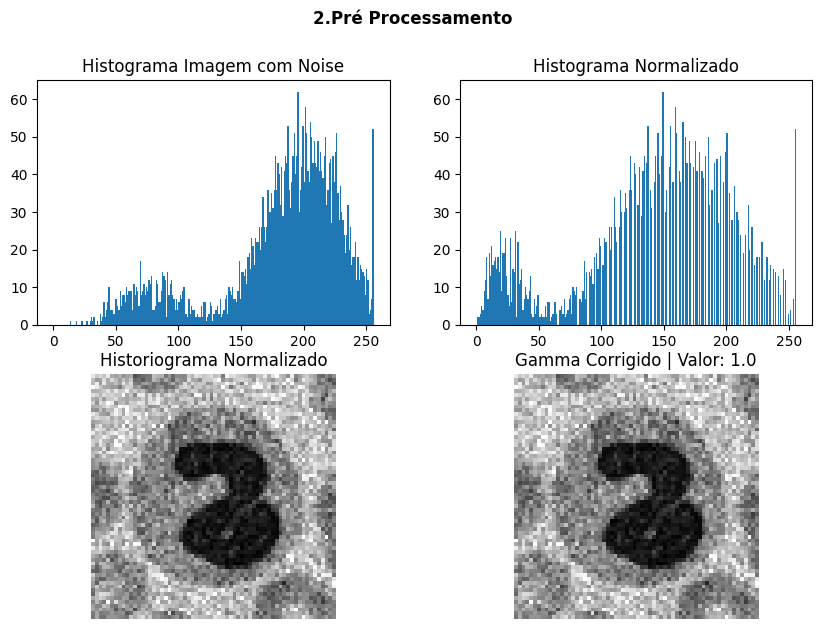

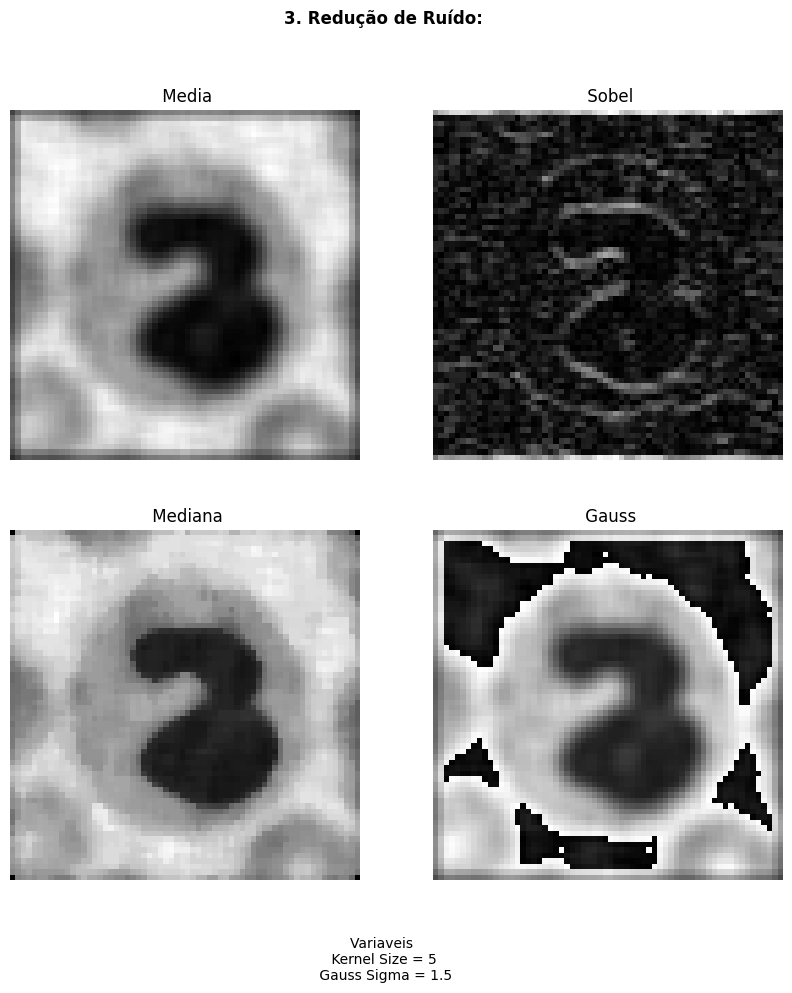

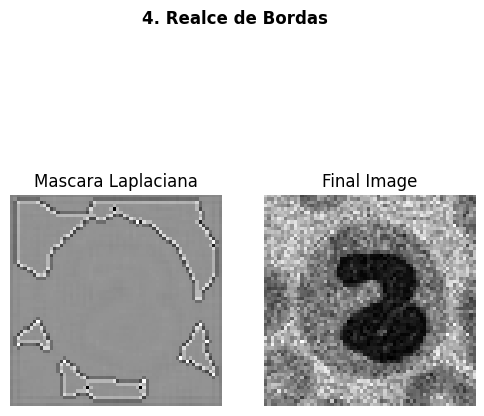

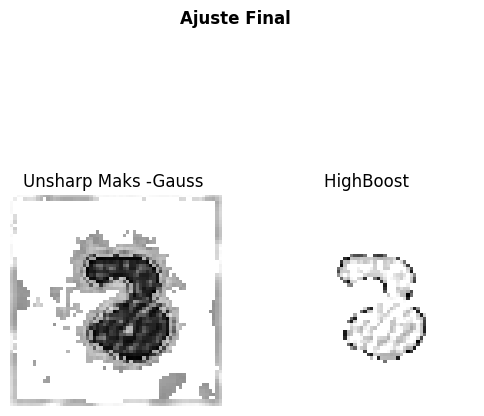

No module named 'pyopencl'


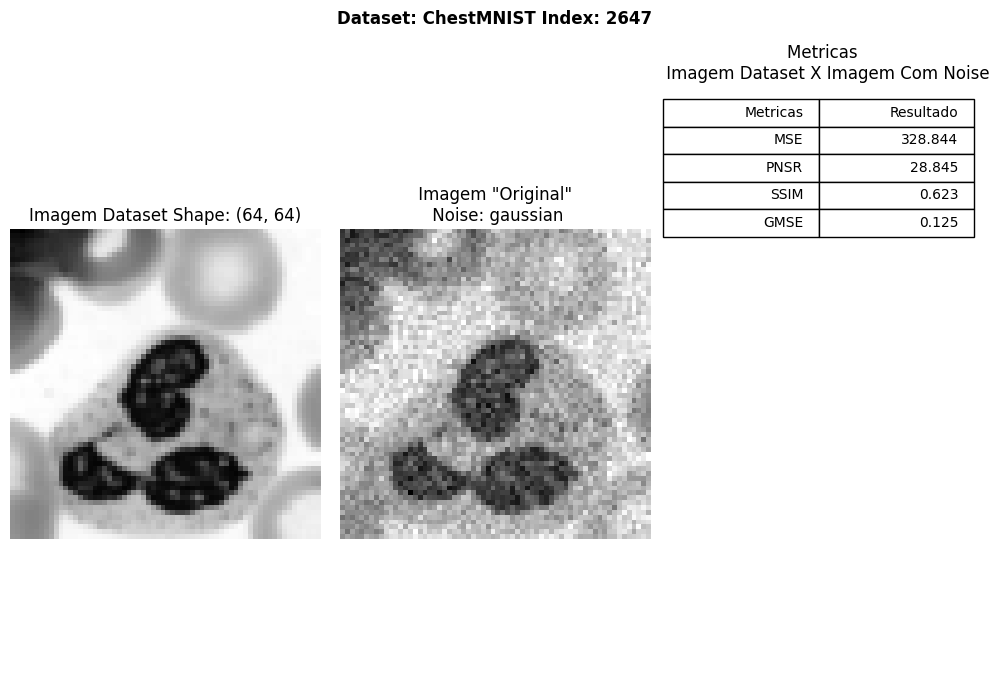

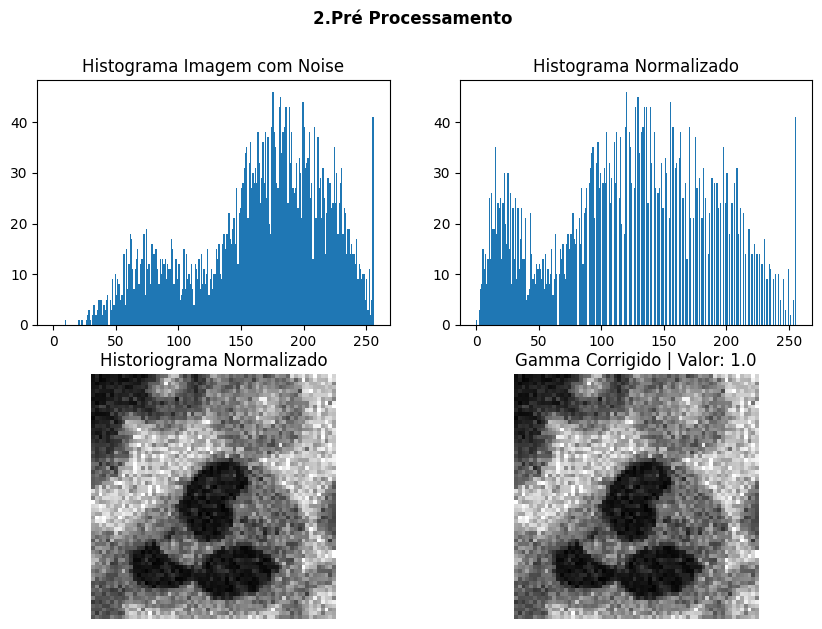

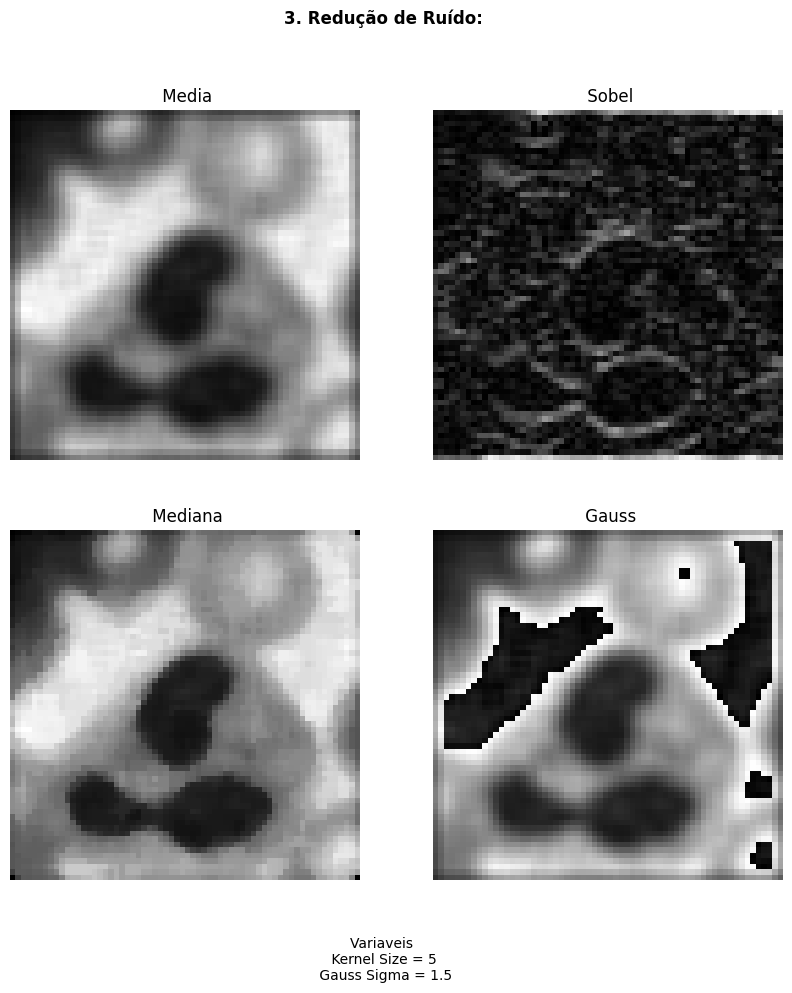

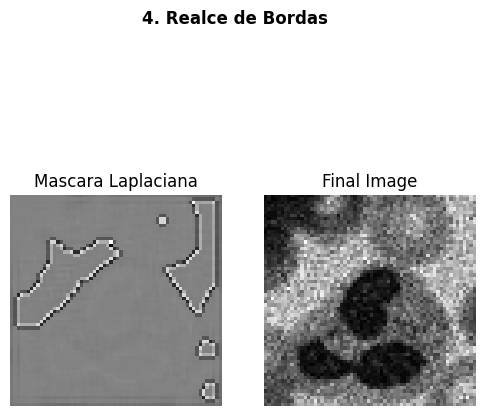

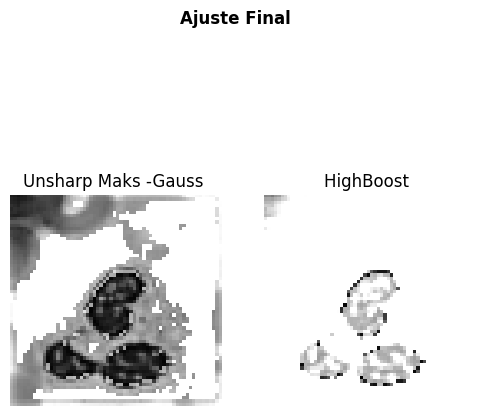

No module named 'pyopencl'


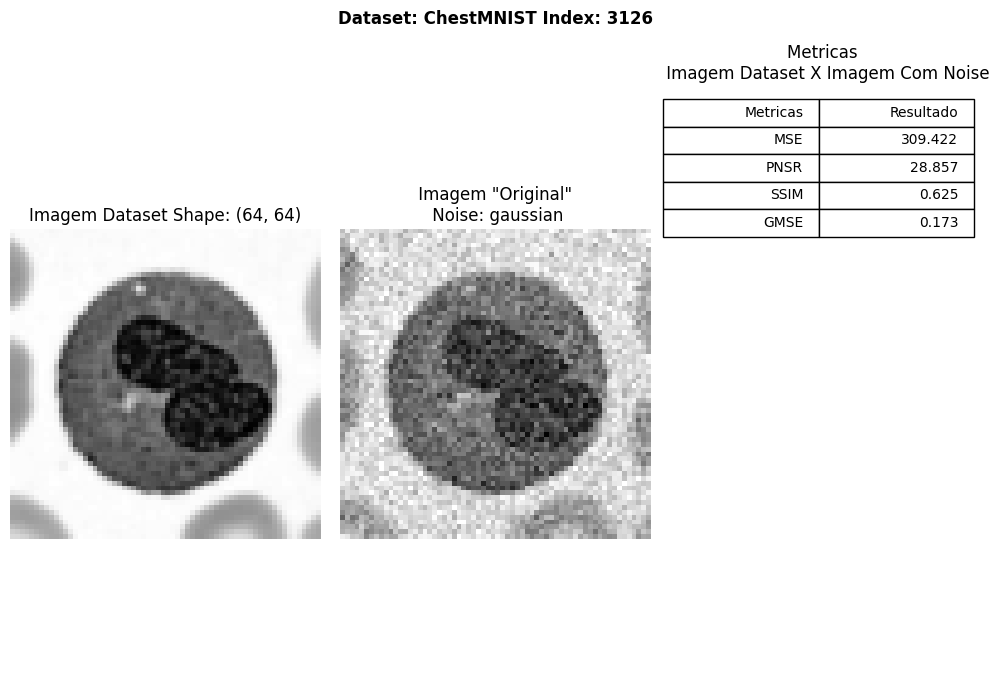

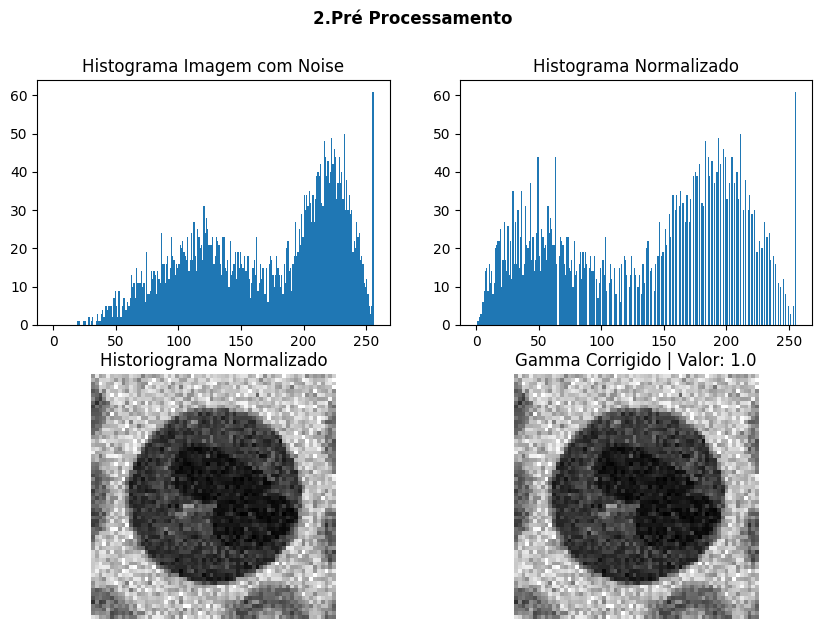

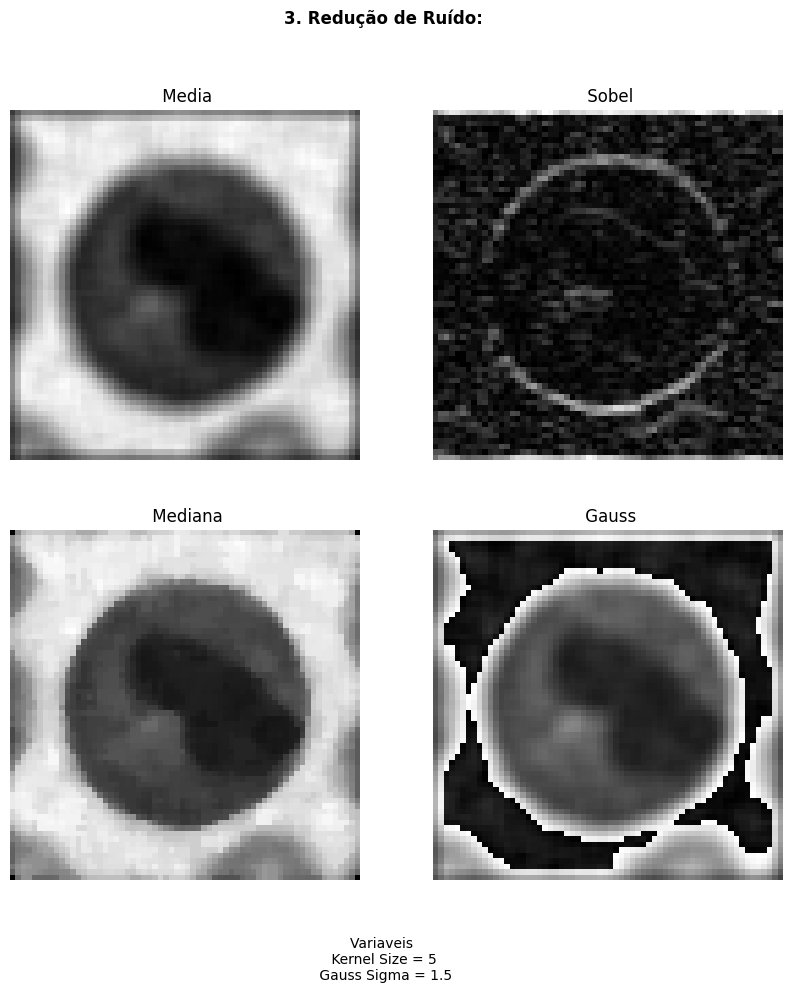

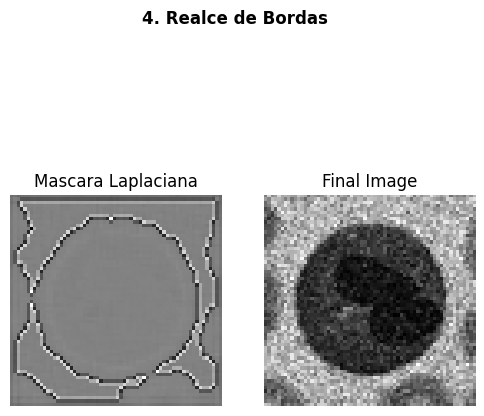

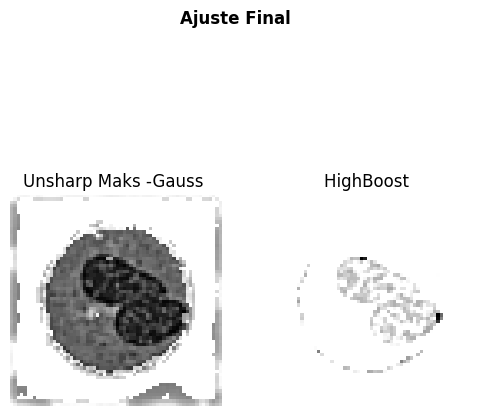

No module named 'pyopencl'


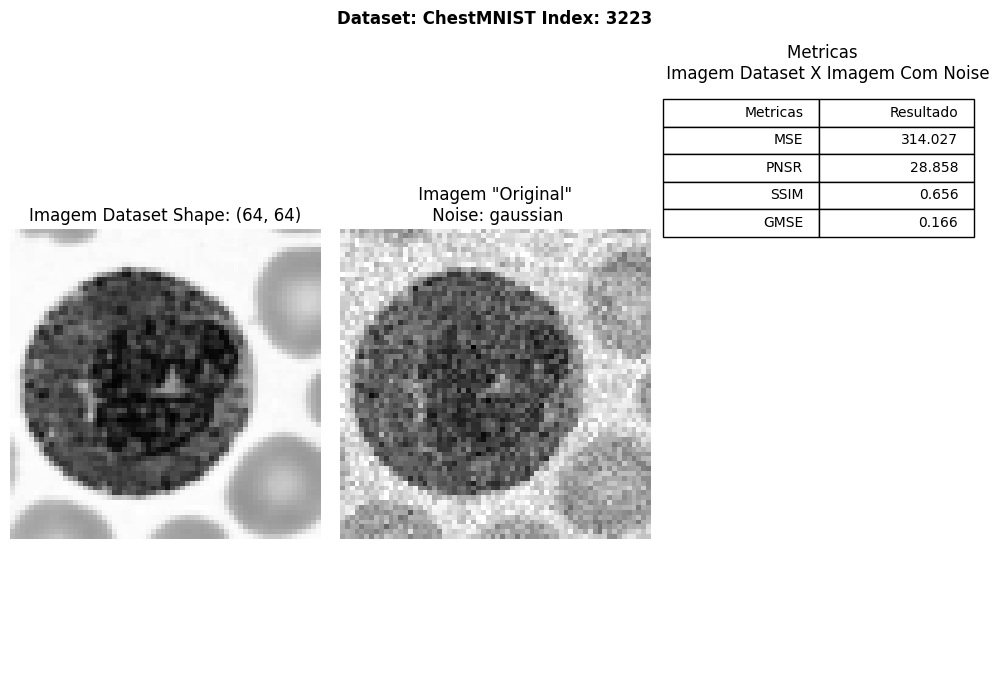

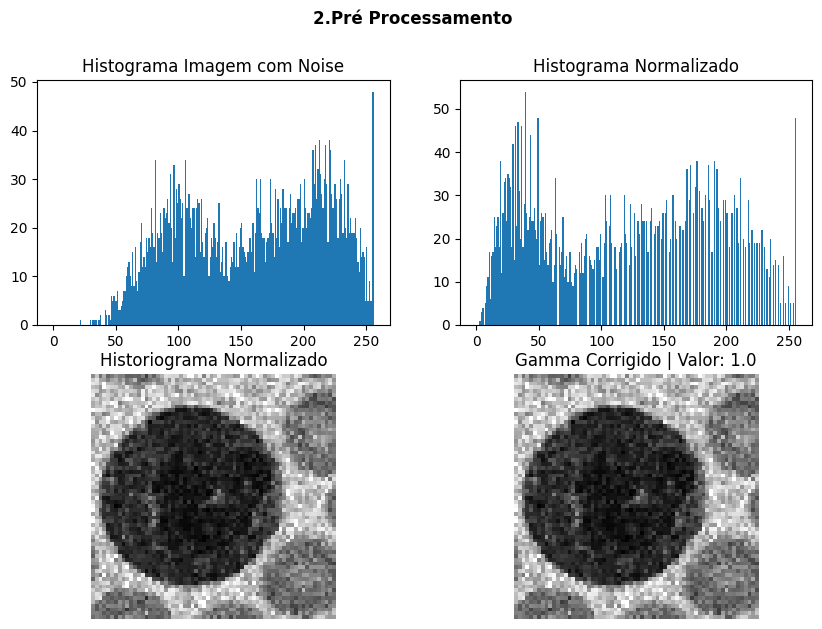

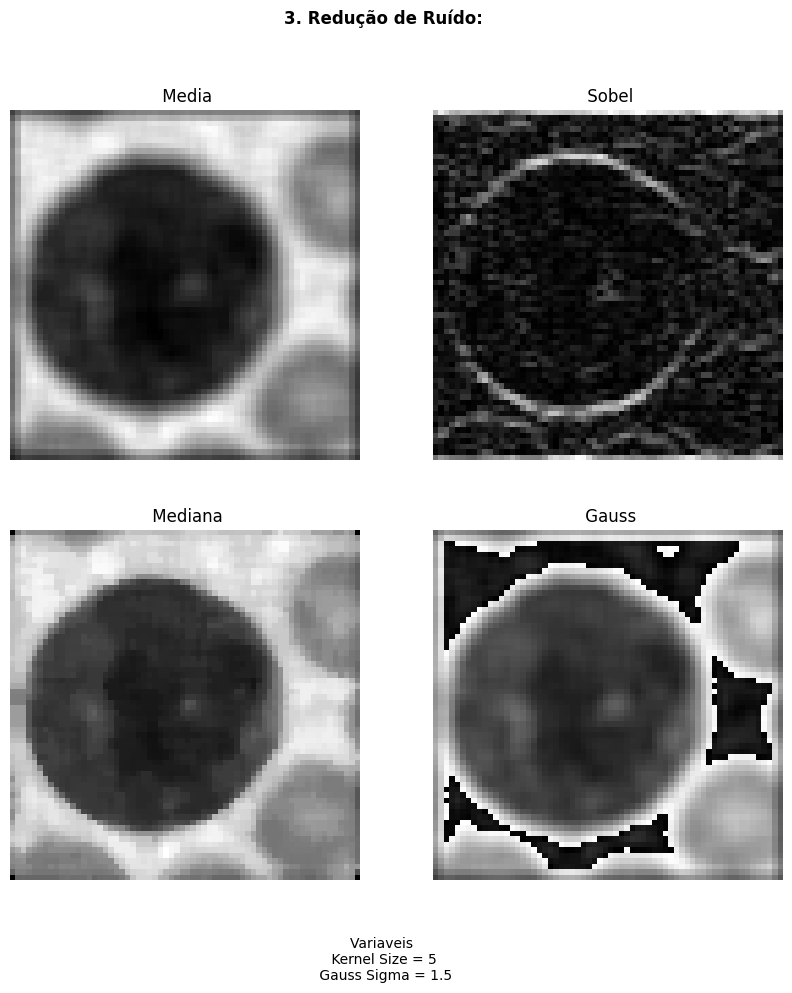

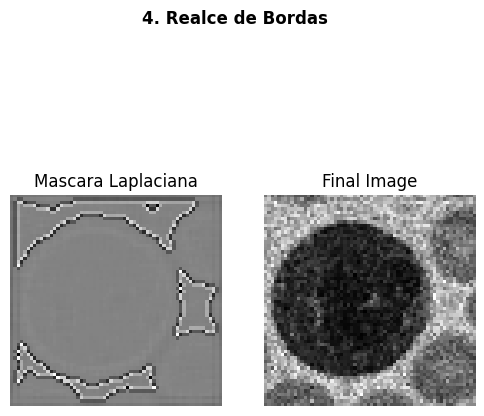

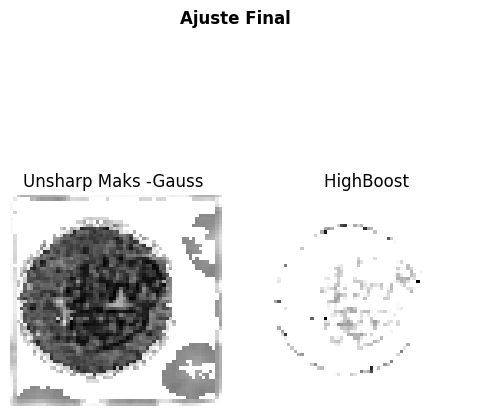

In [ ]:
##
raw_ds = dataset.create_dataset(5, True)
## Noise
modes = [
    "gaussian", 
    "speckle"
]
noise_mode = modes[0]
## Variaveis de Processamento
var_gamma = 1.0
var_k_size = 5
var_gauss_sigma = 1.5
var_f_unsharp = 0.5
var_f_highboost =  4.5


for i in range(len(raw_ds)):
    idx, raw_img = raw_ds[i]
    img = proc.prep_img(raw_img)
    n_img = proc.add_noise(img, noise_mode)
    

    #  Show DataSet
    fig, axes = plt.subplots(1, 3, figsize=(10,7 ))
    fig.suptitle(f"Dataset: ChestMNIST Index: {idx}" , fontsize=12, fontweight='bold')
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Imagem Dataset Shape: {img.shape}')
    axes[0].axis('off')

    axes[1].imshow(n_img, cmap='gray')
    axes[1].set_title(f' Imagem "Original" \n Noise: {noise_mode}')
    axes[1].axis('off')


    data = metricas.data_table(img, n_img)

    # Add table in third axis
    axes[2].axis('off')
    axes[2].set_title("Metricas \n Imagem Dataset X Imagem Com Noise", fontsize=12)
    table = axes[2].table(cellText=data, loc='best')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
   
    plt.tight_layout()
    plt.show()
    ## Historiograma

    ### Transformações
    img_eq = proc.hist_norm(n_img)
    img_gamma = proc.gamma_correction(img_eq, var_gamma)
    ### 2
    fig, axes = plt.subplots(2, 2, figsize=(10,7 ))
    fig.suptitle(f"2.Pré Processamento" , fontsize=12, fontweight='bold')

    axes[0,0].hist(n_img.ravel(), 256, range=[0, 256])
    axes[0,0].set_title('Histograma Imagem com Noise')
    
    axes[0,1].hist(img_eq.ravel(), 256, range=[0, 256])
    axes[0,1].set_title('Histograma Normalizado')

    axes[1,0].imshow(img_eq.astype(np.uint8), cmap='gray')
    axes[1,0].set_title(f'Historiograma Normalizado')
    axes[1,0].axis('off')
    
    axes[1,1].imshow(img_gamma, cmap='gray')
    axes[1,1].set_title(f'Gamma Corrigido | Valor: {var_gamma}')
    axes[1,1].axis('off')

    


    
    gauss_kernel = proc.get_kernel("Gauss", var_k_size, var_gauss_sigma)




    conv_mediana = proc.medianFilter(img_gamma, gauss_kernel )
    conv_gauss = proc.convolution(img_gamma, gauss_kernel)  
    conv_media = proc.convolution(img_gamma, proc.get_kernel("Media", var_k_size))

    #Kernel Tamanho Fixo
    conv_sobel = proc.sobel_conv(img_gamma)


    ### 3
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f"3. Redução de Ruído:" , fontsize=12, fontweight='bold')

   

    axs[0,0].imshow(conv_media, cmap='gray')
    axs[0,0].set_title(f' Media')
    axs[0,0].axis('off')

    axs[0,1].imshow(conv_sobel, cmap='gray')
    axs[0,1].set_title(f' Sobel')
    axs[0,1].axis('off')

    axs[1,0].imshow(conv_mediana, cmap='gray')
    axs[1,0].set_title(f' Mediana')
    axs[1,0].axis('off')
    
    axs[1,1].imshow(conv_gauss, cmap='gray')
    axs[1,1].set_title(f' Gauss')
    axs[1,1].axis('off')

    fig.text(0.5, 0.01, f"Variaveis \n Kernel Size = {var_k_size} \n Gauss Sigma = {var_gauss_sigma}", ha='center', fontsize=10)
    ### 4
    conv_lapac = proc.convolution_sharpening(conv_gauss, proc.get_kernel("laplaciano"))


    lmasked = img_gamma + (conv_lapac * 0.05)
    
    

   
    fig, axes = plt.subplots(1, 2, figsize=(6, 6))
    fig.suptitle(f"4. Realce de Bordas" , fontsize=12, fontweight='bold')
    axes[0].imshow(conv_lapac, cmap='gray')
    axes[0].set_title(f'Mascara Laplaciana')
    axes[0].axis('off')

    axes[1].imshow(lmasked, cmap='gray')
    axes[1].set_title(f'Mascara Aplicada')
    axes[1].axis('off')
   

    f_img = proc.unsharp_mask(img, conv_gauss, var_f_unsharp)


    hb_img = proc.highboost_mask(img, f_img, var_f_highboost)

    ### 5
    fig, axes = plt.subplots(1, 2, figsize=(6, 6))
    fig.suptitle(f"Ajuste Final" , fontsize=12, fontweight='bold')
    axes[0].imshow(f_img, cmap='gray')
    axes[0].set_title(f'Unsharp Maks -Gauss ')
    axes[0].axis('off')

    axes[1].imshow(hb_img, cmap='gray')
    axes[1].set_title(f'HighBoost ')
    axes[1].axis('off')
    


    plt.show()




    



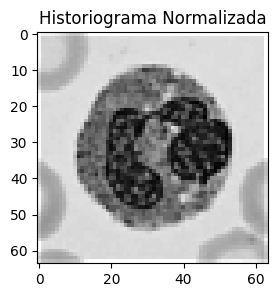

In [58]:


l = proc.unsharp_mask(img, conv_gauss )
plt.figure(figsize=(3, 3))
plt.imshow(l, cmap="gray")
plt.title("Historiograma Normalizada")
plt.show()


### Historiograma

In [59]:


    ## Testes


    #3Show one img

    #plt.figure(figsize=(3, 3))
    #plt.imshow(img_eq, cmap="gray")
    #plt.title("Historiograma Normalizada")
    #plt.show()



    #point_start, point_count = metricas.hist(img)
    #draw_hist(point_start, point_count)
    #plt.title("Histograma Orginal")
    #plt.show()

    ### Normalizaco historigrama pelo cv2
    #img_eq_cv2 = cv2.equalizeHist(n_img)

    #plt.figure(figsize=(3, 3))
    #plt.imshow(img_eq_cv2, cmap="gray")
    #plt.title("Resultado cv2.equalizeHist()")
    #plt.show()
    #point_start, point_count = metricas.hist(img_eq_cv2)
    #draw_hist(point_start, point_count)
    #plt.title("Histograma  cv2.equalizeHist()")
    #plt.show()

